In [4]:
#Get poisson rate for each city
#Get severity distribution for each city
%load_ext autoreload
%autoreload 2
import jax.random as jrand
import matplotlib.pyplot as plt
from stat_utils import grenander_pdf
from abm_event import conditional_sample
from city_data import city_data_base, subsampled_city_data, subsample_weights, subsampled_city_data_names
from stat_utils import CityParams, EventOutcome, GeneralParams, logrange
from abm_ll import event_rate
import pickle
with open('data/county_data.pkl', 'rb') as f:
    city_data = pickle.load(f)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
params = GeneralParams(propensity=1e-6, walk_radius=65, arm_bias=0.01, arm_weight=1.0, atrisk_gathering_rate=1e-6)
c = subsampled_city_data[19]
c_distr = grenander_pdf(conditional_sample(c['params'], params, jrand.PRNGKey(12), int(1e5))+1)
er = event_rate(c['params'], params, 10, c_distr)

In [5]:
import pickle
import numpy as np
# with open('data/ll_eval_153.pkl', 'rb') as f: #Eval over all axis
with open('data/ll_eval_dc111.pkl', 'rb') as f: #2D grid search over propensity, atrisk
    ll_eval = pickle.load(f)
param_groups = list(ll_eval.keys())
ll_sum_l = np.array([(subsample_weights.reshape((-1, 1))*ll_eval[p]).sum(axis=0) for p in param_groups])[:, 0]
# ll_sum_a = np.array([((subsample_weights.reshape((-1, 1))>10)*ll_eval[p]).sum(axis=0) for p in param_groups])[:, 0]*subsample_weights.max()
# ll_sum_b = np.array([((subsample_weights.reshape((-1, 1))<10)*ll_eval[p]).sum(axis=0) for p in param_groups])[:, 0]
# plt.hist(ll_sum_a, bins=np.linspace(-1e4, 0, 1000), alpha=0.5)
# plt.hist(ll_sum_b, bins=np.linspace(-1e4, 0, 1000), alpha=0.5)
# plt.show()


In [6]:
# c = subsampled_city_data[23]
def eval_city_risk(c, param_groups, ll_sum_l):
    randkey = jrand.PRNGKey(12)
    ll_max = ll_sum_l.max()
    wi_l, eri_l = [], []
    for gp, ll_sum in zip(param_groups, ll_sum_l):
        if(ll_sum < ll_max - 10):
            continue
        randkey, subkey = jrand.split(randkey)
        wi = np.exp(ll_sum - ll_max)
        c_distr = grenander_pdf(conditional_sample(c['params'], params, subkey, int(1e5))+1)
        eri = event_rate(c['params'], params, 10, c_distr)
        wi_l.append(wi)
        eri_l.append(eri)
    wi_l = np.array(wi_l)
    eri_l = np.array(eri_l)
    z = wi_l.sum()
    wi_l = wi_l / z
    return (wi_l, eri_l)

# risk_est_l = []
# for city in subsampled_city_data:
#     wi_l, eri_l = eval_city_risk(city, param_groups, ll_sum_l)
#     risk_est = (wi_l*eri_l).sum()
#     risk_est_l.append(risk_est)
# risk_est_l = np.array(risk_est_l)
# with open('data/city_risk_est_dc111.pkl', 'wb') as f:
#     pickle.dump(risk_est_l, f)

In [7]:

with open('data/city_risk_est_dc111.pkl', 'rb') as f:
    risk_est_l = pickle.load(f)
city_pop = np.array([c['params'].population for c in subsampled_city_data])
city_pop_density = np.array([c['params'].population_density for c in subsampled_city_data])
city_arm_densty = np.array([c['params'].arm_density for c in subsampled_city_data])
city_se = np.array([len(c['events']) > 0 for c in subsampled_city_data])
risk_est_norm = risk_est_l / city_pop


In [8]:
sorted_risk = np.argsort(risk_est_l / city_pop)
for i in sorted_risk[-10:]:
    print(subsampled_city_data_names[i], subsampled_city_data[i], risk_est_l[i])

Clifton, New Jersey {'events': [], 'params': CityParams(population=89247, population_density=3056.3, arm_count=2.0, arm_density=0.0684908176185194)} 0.029738480392477288
North Miami Beach, Florida {'events': [], 'params': CityParams(population=43104, population_density=3435.6, arm_count=3.0, arm_density=0.23911469933184856)} 0.016089117716896216
State College, Pennsylvania {'events': [EventOutcome(date='1/24/19', fatalities=3, injured=1, total_victims=4)], 'params': CityParams(population=79803, population_density=3429.7, arm_count=8.0, arm_density=0.34381664849692367)} 0.029846330336428736
Artesia, California {'events': [], 'params': CityParams(population=16044, population_density=3822.7, arm_count=1.0, arm_density=0.2382635253054101)} 0.00667680534861445
Hialeah, Florida {'events': [EventOutcome(date='7/26/2013', fatalities=7, injured=0, total_victims=7)], 'params': CityParams(population=221901, population_density=3969.9, arm_count=10.0, arm_density=0.17890410588505684)} 0.09575705427

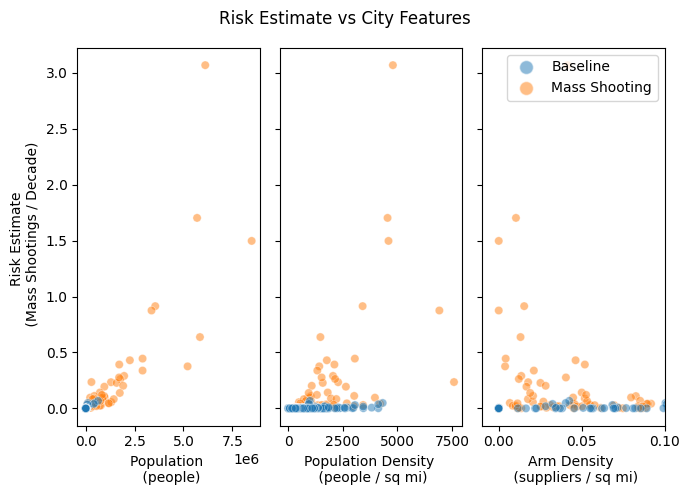

In [18]:
import seaborn as sns
fig, ax = plt.subplots(1, 3, figsize=(7, 5), sharey=True)
color = sns.color_palette('tab10')
sns.scatterplot(x=city_pop, y=risk_est_l, hue=city_se, ax=ax[0], palette=color[:2], alpha=0.5, legend=False)
sns.scatterplot(x=city_pop_density, y=risk_est_l, hue=city_se, ax=ax[1], palette=color[:2], alpha=0.5, legend=False)
sns.scatterplot(x=city_arm_densty, y=risk_est_l, hue=city_se, ax=ax[2], palette=color[:2], alpha=0.5, legend=False)

ax[0].set_xlabel('Population \n (people)')
ax[0].set_ylabel('Risk Estimate \n (Mass Shootings / Decade)')
ax[1].set_xlabel('Population Density \n (people / sq mi)')
ax[2].set_xlabel('Arm Density \n (suppliers / sq mi)')
ax[2].set_xlim(-0.01, 0.1)

ax[2].legend(loc='upper right', 
             handles=[plt.Line2D([0], [0], marker='o', color='w', alpha=0.5, markerfacecolor=color[0], markersize=10), 
                      plt.Line2D([0], [0], marker='o', color='w', alpha=0.5, markerfacecolor=color[1], markersize=10)], 
             labels=['Baseline', 'Mass Shooting'])
fig.set_tight_layout(True)
fig.suptitle('Risk Estimate vs City Features')
plt.show()

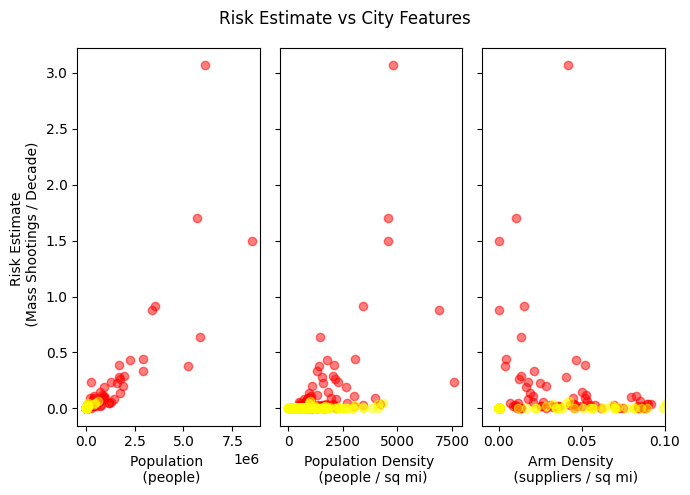

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(7, 5), sharey=True)
ax[0].scatter(city_pop[city_se], risk_est_l[city_se], c='red', alpha=0.5)
ax[0].scatter(city_pop[~city_se], risk_est_l[~city_se], c='yellow', alpha=0.5)
ax[1].scatter(city_pop_density[city_se], risk_est_l[city_se], c='red', alpha=0.5)
ax[1].scatter(city_pop_density[~city_se], risk_est_l[~city_se], c='yellow', alpha=0.5)
ax[2].scatter(city_arm_densty[city_se], risk_est_l[city_se], c='red', alpha=0.5)
ax[2].scatter(city_arm_densty[~city_se], risk_est_l[~city_se], c='yellow', alpha=0.5)

ax[0].set_xlabel('Population \n (people)')
ax[0].set_ylabel('Risk Estimate \n (Mass Shootings / Decade)')
ax[1].set_xlabel('Population Density \n (people / sq mi)')
ax[2].set_xlabel('Arm Density \n (suppliers / sq mi)')
ax[2].set_xlim(-0.01, 0.1)
fig.set_tight_layout(True)
fig.suptitle('Risk Estimate vs City Features')
plt.show()

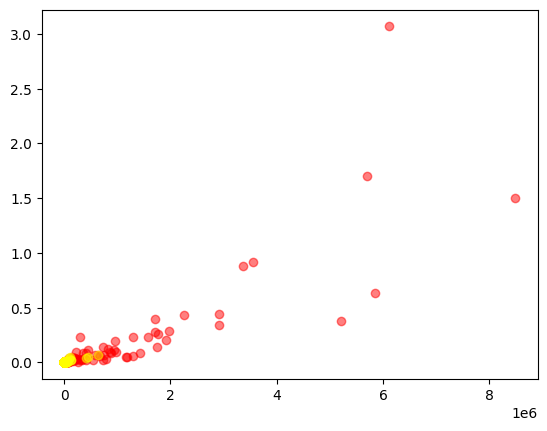

In [ ]:
plt.scatter(city_pop[city_se], risk_est_l[city_se], c='red', alpha=0.5)
plt.scatter(city_pop[~city_se], risk_est_l[~city_se], c='yellow', alpha=0.5)


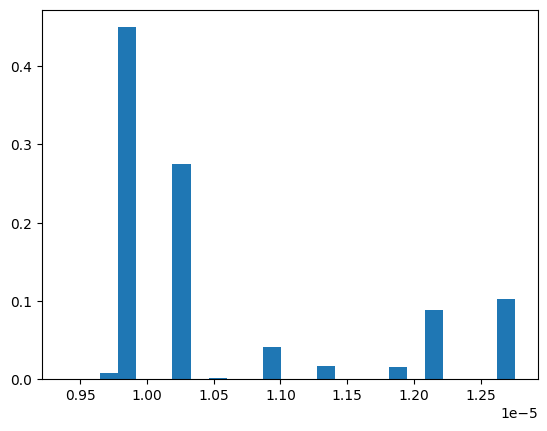

In [26]:
plt.hist(eri_l, bins=25, weights=wi_l)
plt.show()

In [21]:
np.min(eri_l), np.max(eri_l)

(0.010229701258149248, 0.011673024114548363)